In [73]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat, savemat

In [74]:
PATH = os.path.join("..", "content", "mnist_original.mat")

In [75]:
CLUSTERS = 856
EPOCHS = 10
SAMPLES = 60000

In [76]:
mnist = loadmat(PATH)
mnist_data, mnist_label = np.array(mnist["data"].T), np.array(mnist["label"][0].T)
train_mnist_data, test_mnist_data = mnist_data[:SAMPLES], mnist_data[SAMPLES:]
train_mnist_label, test_mnist_label = mnist_label[:SAMPLES], mnist_label[SAMPLES:]

# MAKING THE TARGET MODEL

In [77]:
from sklearn.cluster import KMeans
from scipy.stats import mode

In [78]:
k_means = KMeans(n_clusters=CLUSTERS, n_init="auto", max_iter=EPOCHS, random_state=42)
k_means.fit(train_mnist_data)
pred_train_mnist_label = k_means.predict(train_mnist_data)

In [79]:
cluster_labels = np.zeros(CLUSTERS, dtype=int)
for i in range(CLUSTERS):
    mask = pred_train_mnist_label == i
    cluster_labels[i] = mode(train_mnist_label[mask], keepdims=True).mode[0]

In [80]:
pred_test_mnist_label = cluster_labels[k_means.predict(test_mnist_data)]
accuracy = np.mean(pred_test_mnist_label == test_mnist_label)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 94.01%


# MAKING THE SURROGATE MODEL

In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models

In [82]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using {device}")

using cuda


In [83]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].reshape(28, 28).astype(np.uint8)
        if self.transform:
            img = self.transform(img)
        label = int(self.labels[idx])
        return img, label

In [84]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [85]:
train_dataset = MNISTDataset(train_mnist_data, train_mnist_label, transform=transform)
test_dataset = MNISTDataset(test_mnist_data, test_mnist_label, transform=transform)

In [86]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [87]:
model = models.resnet18(weights=None) # No pre-trained weights
model.fc = nn.Linear(model.fc.in_features, 10) # 10 classes for MNIST
model = model.to(device)

In [88]:
criterion = nn.CrossEntropyLoss() # loss function
optimizer = optim.Adam(model.parameters(), lr=0.001) # learning rate set to 0.001

In [89]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

In [90]:
MODEL_OR = os.path.join("..", "models", "resnet18_mnist_surrogate_or.pth")

In [91]:
torch.save(model.state_dict(), MODEL_OR)

In [92]:
model.load_state_dict(torch.load(MODEL_OR))

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 99.38%


# ITERATIVE FAST GRADIENT SIGN METHOD
## TRYING RANGE OF PARAMETERS

In [93]:
from art.attacks.evasion import BasicIterativeMethod
from art.estimators.classification import PyTorchClassifier

In [94]:
SUBSET = 1000
ITERATIONS = 30

In [95]:
classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 224, 224),
    nb_classes=10,
    device_type=device
)

In [96]:
inverse_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28))
])

In [97]:
test_accuracies = []
adv_test_accuracies = []
epsilon_values = []

In [98]:
for iteration in range(0, ITERATIONS + 1):
    epsilon = iteration / ITERATIONS
    beta = 40

    attack = BasicIterativeMethod(
        estimator=classifier,
        eps=epsilon,
        eps_step=beta,
        max_iter=EPOCHS,
        targeted=False,
        batch_size=32
    )

    subset_indices_train = np.random.choice(len(train_dataset), SUBSET, replace=False)
    subset_images_train = torch.stack([train_dataset[i][0] for i in subset_indices_train]).to(device)
    subset_labels_train = train_mnist_label[subset_indices_train]  

    adversarial_train_images = attack.generate(x=subset_images_train.cpu().numpy())
    
    adversarial_train_flat = []
    for adv_img in adversarial_train_images:
        adv_tensor = torch.from_numpy(adv_img)
        adv_pil = inverse_transform(adv_tensor)
        adv_np = np.array(adv_pil).flatten()
        adversarial_train_flat.append(adv_np)
    
    adversarial_train_flat = np.array(adversarial_train_flat)

    subset_indices_test = np.random.choice(len(test_dataset), SUBSET, replace=False)  
    subset_images_test = torch.stack([test_dataset[i][0] for i in subset_indices_test]).to(device)
    subset_labels_test = test_mnist_label[subset_indices_test]  

    adversarial_test_images = attack.generate(x=subset_images_test.cpu().numpy())
    
    adversarial_test_flat = []
    for adv_img in adversarial_test_images:
        adv_tensor = torch.from_numpy(adv_img)
        adv_pil = inverse_transform(adv_tensor)
        adv_np = np.array(adv_pil).flatten()
        adversarial_test_flat.append(adv_np)
    
    adversarial_test_flat = np.array(adversarial_test_flat)

    combined_images = np.vstack([train_mnist_data, adversarial_train_flat])
    combined_labels = np.concatenate([train_mnist_label, subset_labels_train])
    
    k_means_robust = KMeans(n_clusters=CLUSTERS, n_init="auto", max_iter=EPOCHS, random_state=42)
    k_means_robust.fit(combined_images)
    pred_combined_labels = k_means_robust.predict(combined_images)
    
    cluster_labels_robust = np.zeros(CLUSTERS, dtype=int)
    for i in range(CLUSTERS):
        mask = pred_combined_labels == i
        cluster_labels_robust[i] = mode(combined_labels[mask], keepdims=True).mode[0]
    
    pred_test = cluster_labels_robust[k_means_robust.predict(test_mnist_data)]
    test_accuracy = np.mean(pred_test == test_mnist_label)
    
    pred_adv_test = cluster_labels_robust[k_means_robust.predict(adversarial_test_flat)]
    adv_test_accuracy = np.mean(pred_adv_test == subset_labels_test)
    
    epsilon_values.append(epsilon)
    test_accuracies.append(test_accuracy)
    adv_test_accuracies.append(adv_test_accuracy)

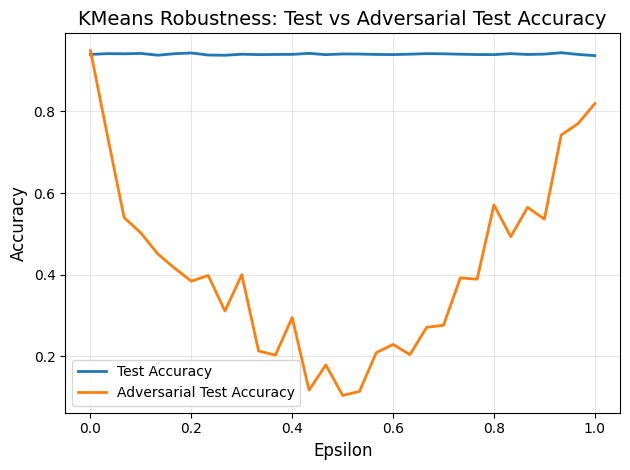

In [ ]:
plt.plot(epsilon_values, test_accuracies, label='Test Accuracy', linewidth=2)
plt.plot(epsilon_values, adv_test_accuracies, label='Adversarial Test Accuracy', linewidth=2)
plt.xlabel('Epsilon', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KMeans Robustness: Test vs Adversarial Test Accuracy', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()